## Notebook that should cleanly look at the results of recent optimisations

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json
import sys
import os
import jax.numpy as jnp

from nrt import losses
from nrt import helper_functions
from nrt import plotters
from sweep_analysis import generate_analysis_plots, generate_loss_plots, generate_2d_plots, generate_1d_plots

# %cd /Users/will/Documents/Neural_Rep_Theory/11_June_Norm/

In [ ]:
day = '251127'
time = 'original'
counter = 4
save_fig = 0
plot_scale = 1

if counter == '':
    adding_string = ''
else:
    adding_string = '_'

%cd /home/julian/Projects/MasterThesis/ICLR_Actionable_Reps
filepath = './data/' + day + '/' + time + '/'
%cd "$filepath"

# Use the generate_analysis_plots function to create all plots
savepath = os.getcwd()
figures = generate_analysis_plots(savepath, counter=counter, save_fig=save_fig, plot_scale=plot_scale)

# Display all generated figures
for fig_name, fig in figures.items():
    plt.figure(fig.number)
    plt.show()

# Load parameters for inspection
with open('parameters.json', 'r') as json_file:
    parameters = json.load(json_file)

print("\nParameters:")
parameters

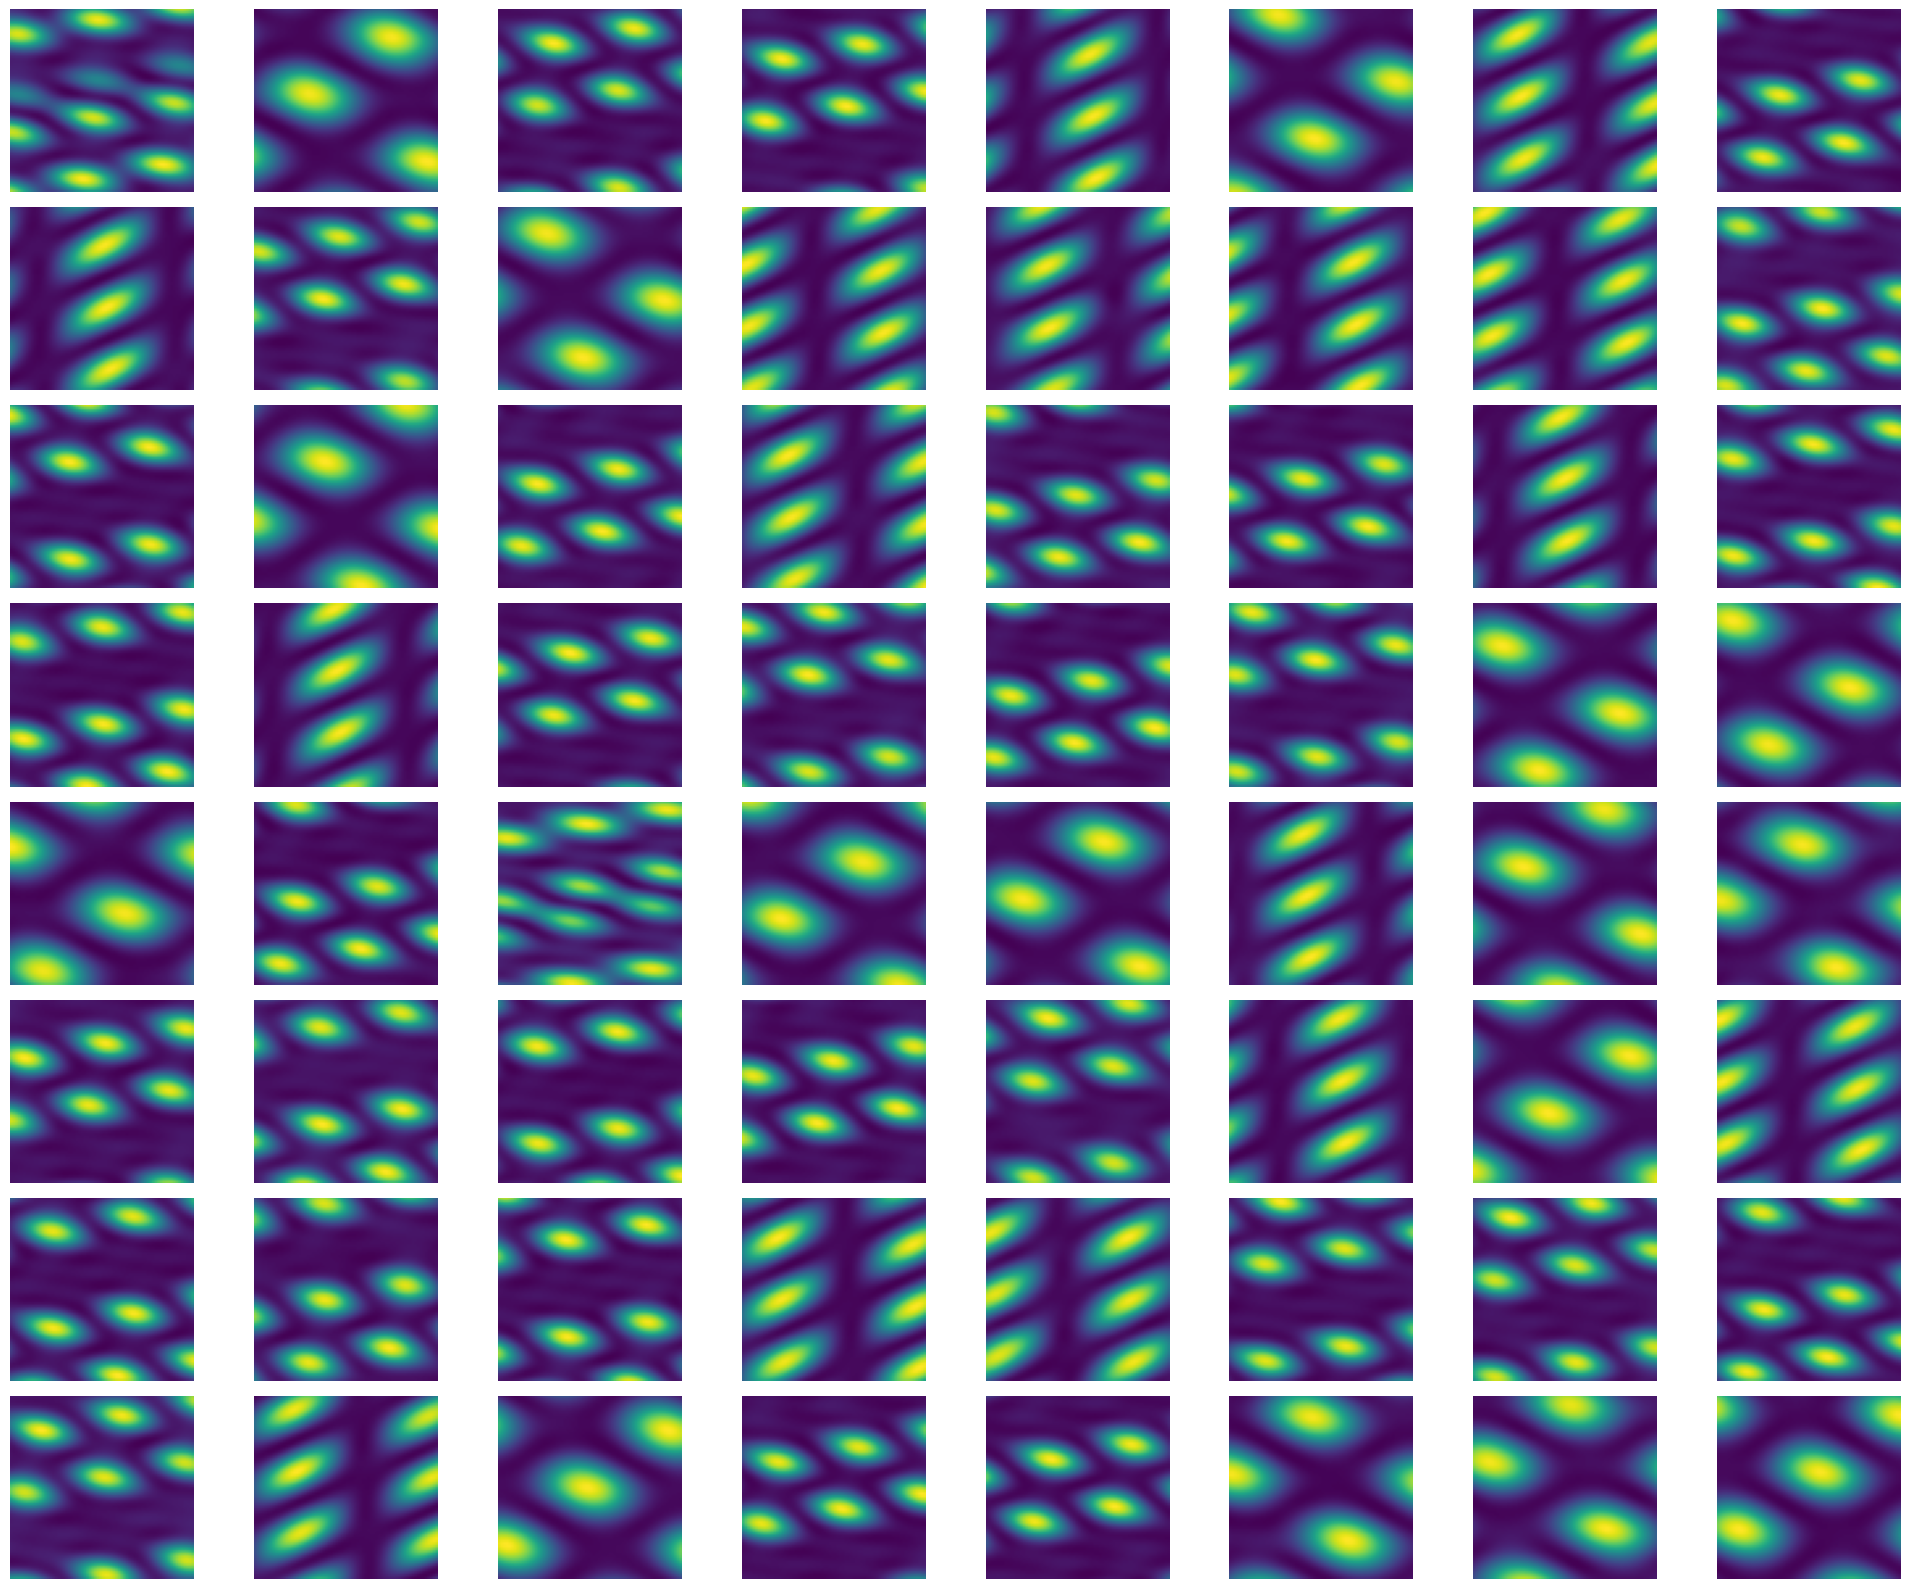

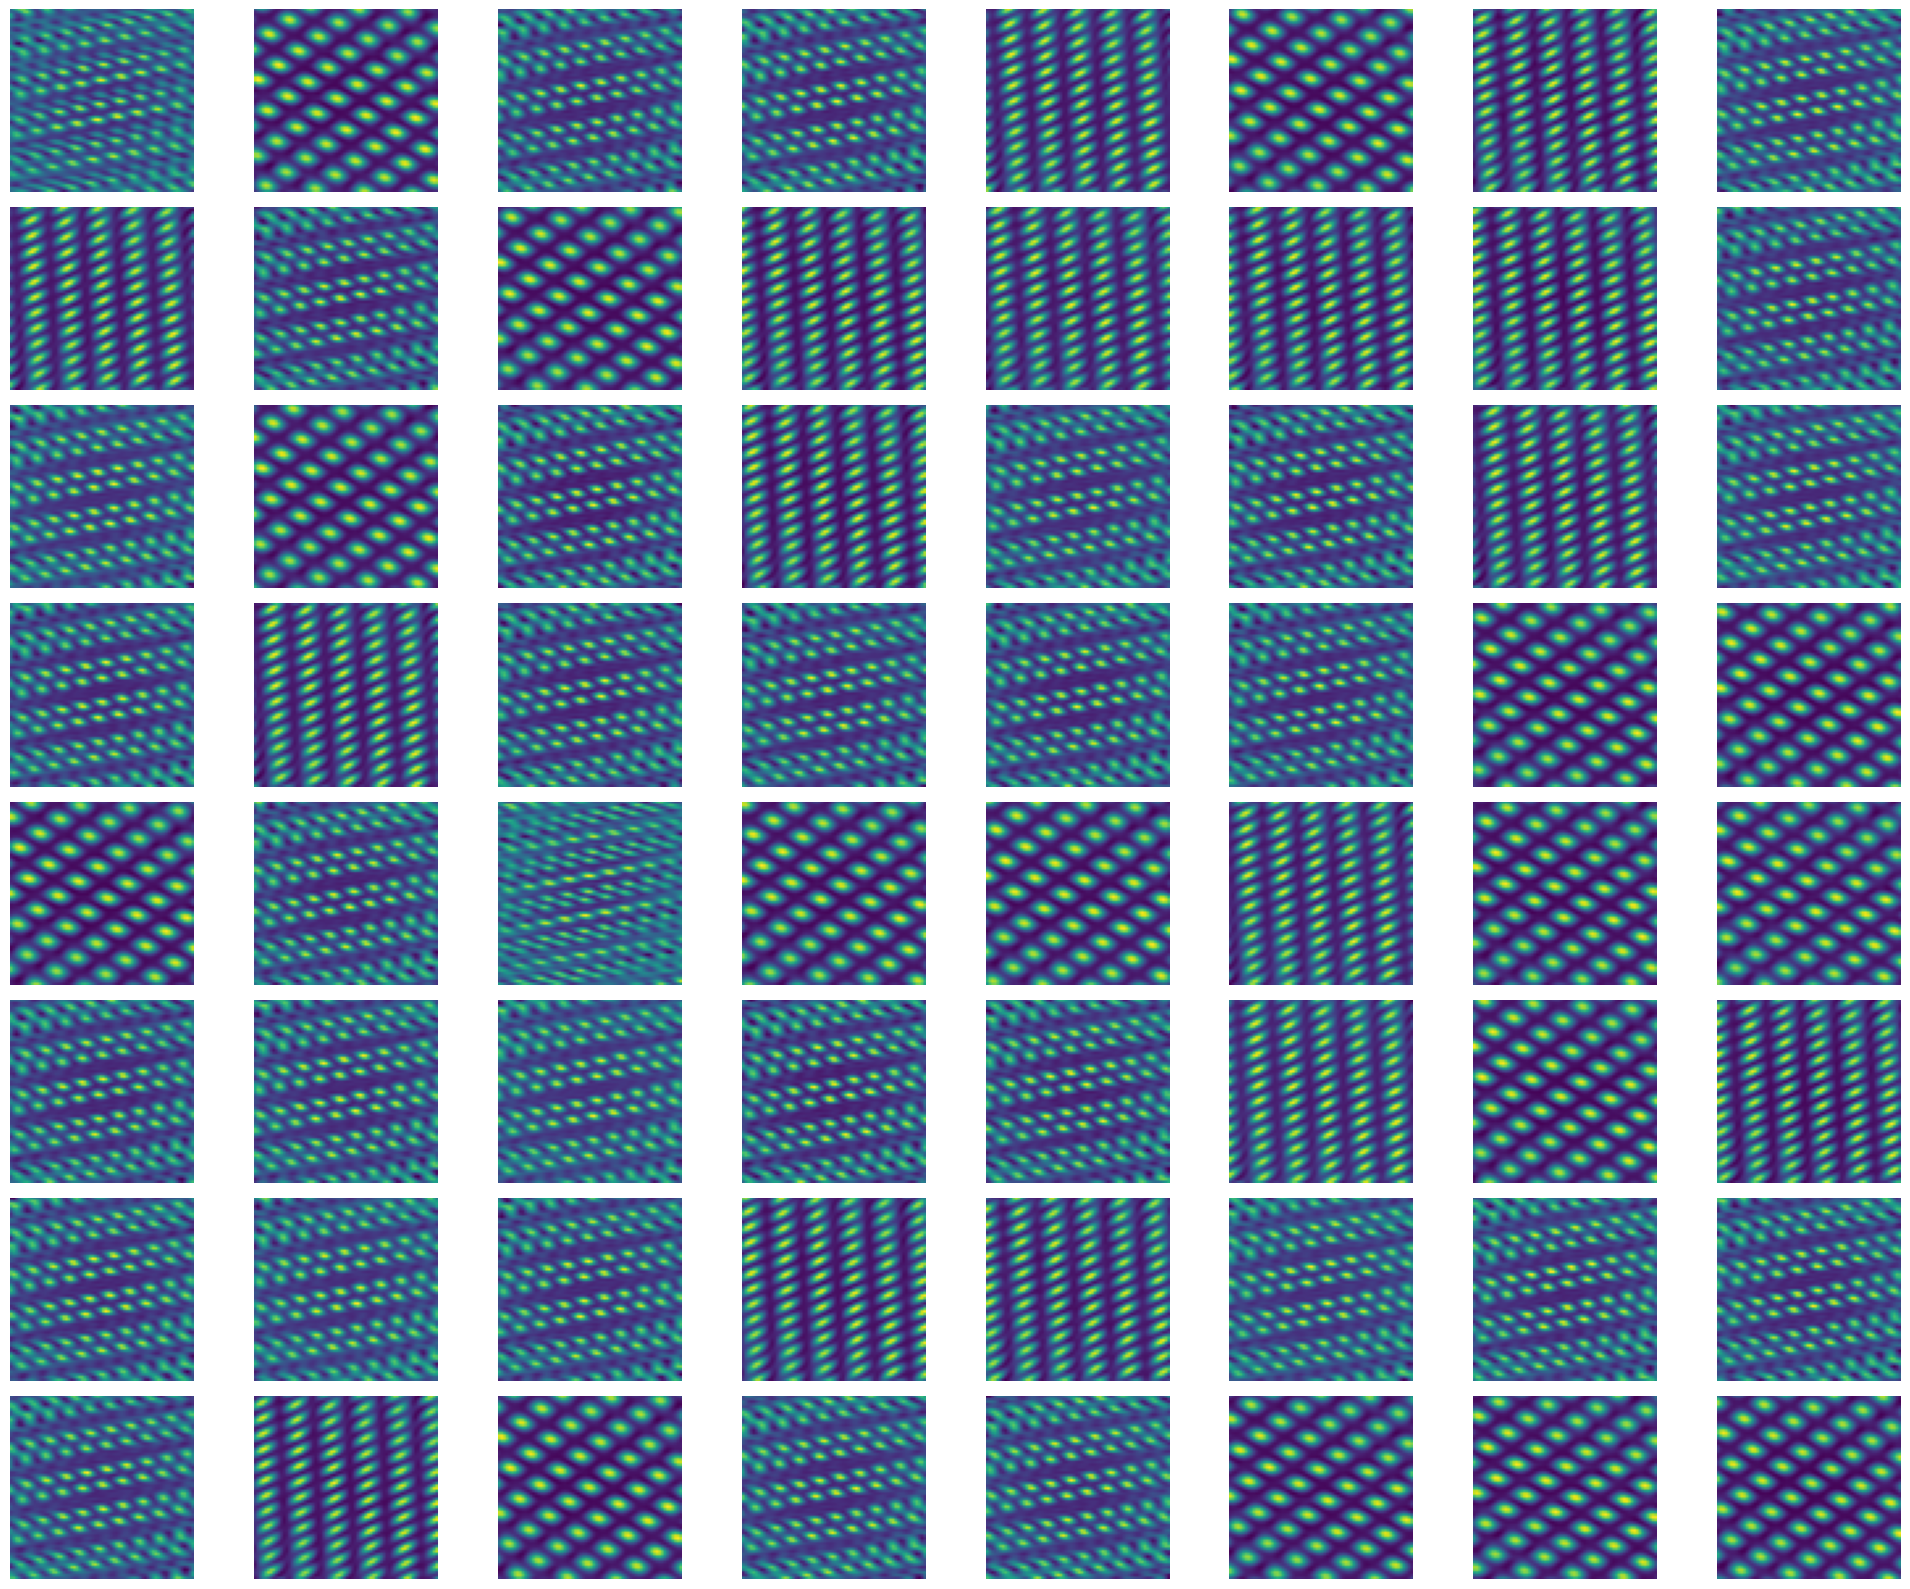

In [3]:
for (plot_counter, V_plot) in enumerate(Vs):
    fig = plt.figure(figsize = (20, 16))
    for neuron in range(parameters["D"]):
        plt.subplot(RowsD, ColumnsD, neuron + 1)
        plt.axis('off')
        plt.imshow(np.reshape(V_plot[neuron,:], [N_plot,N_plot]))
        #plt.title(f"{neur_losses[neuron]:.3f}")
        #plt.colorbar()
        ax = plt.gca()
        ax.patch.set_edgecolor('black')  

        ax.patch.set_linewidth('10')  
    #plt.suptitle(loss)
    fig.tight_layout()
    plot_counter = plot_counter + 1
    plt.show()
    fig.savefig(f"Neurons_Plot_{plot_counter}.svg")
    #print(loss)
    if parameters["sep_loss_choice"] < 2:
        print(parameters["D"]*min(neur_losses))



In [4]:
parameters

{'D': 64,
 'T': 150000,
 'K': 1,
 'N_rand': 150,
 'phi_std': 1,
 'N_shift': 15,
 'resample_iters': 5,
 'save_iters': 5,
 'lambda_pos_init': 0.1,
 'k_p': -9,
 'alpha_p': 0.9,
 'gamma_p': 0.0001,
 'lambda_norm_init': 0.005,
 'k_norm': -5.25,
 'alpha_norm': 0.9,
 'gamma_norm': 0.0001,
 'beta1': 0.9,
 'beta2': 0.9,
 'eta': 1e-08,
 'epsilon_w': 0.1,
 'epsilon_om': 0.1,
 'dim': 2,
 'sampling_choice': 1,
 'norm_size': 1,
 'Shift_std': 3,
 'shift_points_sep': 0,
 'om_init_scheme': 0,
 'om_init_scale': 2,
 'sigma_sq': 0.04,
 'sigma_theta': 0.5,
 'f': 1,
 'chi_choice': 0,
 'sep_loss_choice': 3,
 'pos_lengthscale': 2}

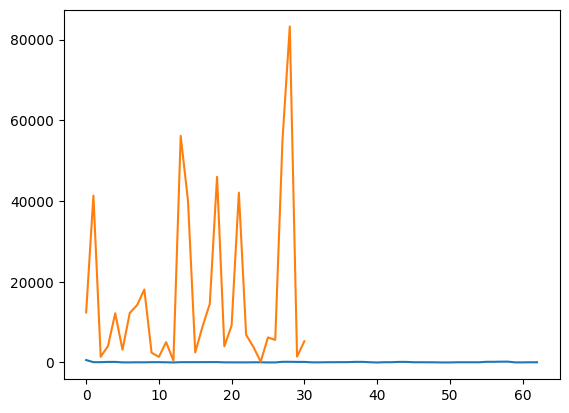

In [5]:
plt.plot(np.linalg.norm(W_final, axis = 0))
weights = np.linalg.norm(W_final, axis = 0)[1:]
weights = weights[::2]**2 + weights[1::2]**2
plt.plot(weights)

In [6]:
om[weights > 0.01,:]

Array([[  0.5790928 ,   4.624478  ],
       [  2.3704774 ,   5.806981  ],
       [  2.5968273 ,   5.387325  ],
       [  2.7468646 , -11.063283  ],
       [  0.9354318 ,   4.4007688 ],
       [  0.3189584 ,  -0.20835534],
       [ -1.0171417 ,  -4.8789444 ],
       [  3.7352703 ,  -1.1065623 ],
       [ -0.29861137,   5.9862995 ],
       [  2.8422565 ,  -8.896752  ],
       [  0.20144026,  -5.5235996 ],
       [  4.4362097 ,   0.39247054],
       [ -2.0292614 , -11.696389  ],
       [  1.7012409 ,   2.42738   ],
       [  3.3401935 ,  -6.485081  ],
       [  2.6496623 ,  -8.896931  ],
       [  5.1078176 ,   2.7608838 ],
       [  5.065948  ,   5.612995  ],
       [  0.4034889 ,   2.2743697 ],
       [  0.21587306,   0.35716048],
       [ -1.268045  ,  -6.5903006 ],
       [  2.0385096 ,  -3.564353  ],
       [ -1.549375  ,  -7.159634  ],
       [  2.2170296 , -11.288493  ],
       [  5.841866  ,   5.3582296 ],
       [ -0.93949574,  -7.0647254 ],
       [  4.7101235 ,   0.20483701],
 

In [7]:
def init_irreps_2D(om, phi):
    cos_stack = jnp.cos(jnp.sum(phi[None,:,:]*om[:,None,:], axis = 2))
    sin_stack = jnp.sin(jnp.sum(phi[None,:,:]*om[:,None,:], axis = 2))
    I = jnp.ones([2*jnp.shape(om)[0] + 1, jnp.shape(phi)[0]])
    I = I.at[1::2,:].set(cos_stack)
    I = I.at[2::2,:].set(sin_stack)
    return I


In [8]:
# Sample a load of points
N_plot = 50
phi_plot_large = np.linspace(-np.pi, np.pi, N_plot)
phi_plot_large = np.meshgrid(phi_plot_large, phi_plot_large, phi_plot_large)
phi_plot_large = np.hstack([np.ndarray.flatten(phi_plot_large[0])[:,None], np.ndarray.flatten(phi_plot_large[1])[:,None], np.ndarray.flatten(phi_plot_large[2])[:,None]])

I = init_irreps_2D(om, phi_plot_large)
V = np.matmul(W_final, I)

TypeError: mul got incompatible shapes for broadcasting: (1, 125000, 3), (31, 1, 2).

In [ ]:
fig = plt.figure(figsize = (16, 6))

for neuron in range(5):
    ax = fig.add_subplot(2, 5, neuron + 1, projection='3d')

    ax.scatter(phi_plot_large[:,0],  phi_plot_large[:,1], phi_plot_large[:,2], c = V[neuron,:], alpha = 0.3)

    ax.view_init(elev=45, azim=45)
    ax.get_xaxis().set_ticks([])
    ax.get_yaxis().set_ticks([])
    ax.get_zaxis().set_ticks([])
    
plt.savefig('3D_Grids.svg')

In [ ]:
fig = plt.figure(figsize = (6, 6))
ax = fig.add_subplot(1, 1,  1, projection='3d')
ax.scatter(phi_plot_large[:,0],  phi_plot_large[:,1], phi_plot_large[:,2], c = V[neuron,:], alpha = 0.3)